## Analysis of an E-commerce Dataset Part 2

The goal of the second analysis task is to train linear regression models to predict users' ratings towards items. This involves a standard Data Science workflow: exploring data, building models, making predictions, and evaluating results. In this task, we will explore the impacts of feature selections and different sizes of training/testing data on the model performance. We will use another cleaned combined e-commerce sub-dataset that **is different from** the one in “Analysis of an E-commerce Dataset” task 1.

### Import Cleaned E-commerce Dataset
The csv file named 'cleaned_ecommerce_dataset.csv' is provided. You may need to use the Pandas method, i.e., `read_csv`, for reading it. After that, please print out its total length.

In [25]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline


data = pd.read_csv("/Users/macbook/Desktop/MQ/Session 1 - 2024/COMP2200 - Data Science/Portfolio/Portfolio 2/portfolio-part-2-zvktah/cleaned_ecommerce_dataset.csv")

data

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4
...,...,...,...,...,...,...,...,...,...,...,...
2680,2445,22000,Great movie!,Austin Powers: The Spy Who Shagged Me,5.0,3.0,M,Movies,9,111.00,5
2681,2445,30700,Good food!,Outback Steakhouse,5.0,3.0,M,Restaurants & Gourmet,50,25.00,5
2682,2445,61500,Great movie!,Fight Club,5.0,3.0,M,Movies,26,97.53,5
2683,2445,100500,Awesome Game.,The Sims 2: Open for Business for Windows,5.0,4.0,M,Games,79,27.00,5


In [2]:
# Print out the total length

print("\nThe total length of data is", len(data))


The total length of data is 2685


### Explore the Dataset

* Use the methods, i.e., `head()` and `info()`, to have a rough picture about the data, e.g., how many columns, and the data types of each column.
* As our goal is to predict ratings given other columns, please get the correlations between helpfulness/gender/category/review and rating by using the `corr()` method.

  Hints: To get the correlations between different features, you may need to first convert the categorical features (i.e., gender, category and review) into numerial values. For doing this, you may need to import `OrdinalEncoder` from `sklearn.preprocessing` (refer to the useful exmaples [here](https://pbpython.com/categorical-encoding.html))
* Please provide ___necessary explanations/analysis___ on the correlations, and figure out which are the ___most___ and ___least___ corrleated features regarding rating. Try to ___discuss___ how the correlation will affect the final prediction results, if we use these features to train a regression model for rating prediction. In what follows, we will conduct experiments to verify your hypothesis.

In [3]:
# Display head of data

data.head(10)

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4
5,4081,100399,Good for sci-fi,Matrix,3.0,3.0,M,Movies,40,24.51,4
6,4081,100399,Scary? you bet!,Blair Witch Project,4.0,3.0,M,Movies,12,44.00,4
7,4081,101899,Fox - the 4th basic channel,FOX,4.0,4.0,M,Media,25,80.00,4
8,4081,112099,Amen!,Dogma,4.0,3.0,M,Movies,22,87.59,4
9,4081,122899,mama mia!,Olive Garden,4.0,3.0,M,Restaurants & Gourmet,49,32.00,4


In [4]:
# Display data info about how many columns, and the data types of each column.

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2685 entries, 0 to 2684
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   userId       2685 non-null   int64  
 1   timestamp    2685 non-null   int64  
 2   review       2685 non-null   object 
 3   item         2685 non-null   object 
 4   rating       2685 non-null   float64
 5   helpfulness  2685 non-null   float64
 6   gender       2685 non-null   object 
 7   category     2685 non-null   object 
 8   item_id      2685 non-null   int64  
 9   item_price   2685 non-null   float64
 10  user_city    2685 non-null   int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 230.9+ KB


In [5]:
# Display the amount of null values

data.isnull().sum()

userId         0
timestamp      0
review         0
item           0
rating         0
helpfulness    0
gender         0
category       0
item_id        0
item_price     0
user_city      0
dtype: int64

In [50]:
# Use OrdinalEncoder function from sklearn.preprocessing to convert the categorical features

from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
data["gender_id"] = ord_enc.fit_transform(data[["gender"]])
data["category_id"] = ord_enc.fit_transform(data[["category"]])
data["review_id"] = ord_enc.fit_transform(data[["review"]])

# Show data after add new converted categorical features

data.head(10)

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city,gender_id,category_id,review_id
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4,1.0,8.0,1618.0
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4,1.0,8.0,1125.0
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4,1.0,8.0,2185.0
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4,1.0,5.0,2243.0
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4,1.0,5.0,1033.0
5,4081,100399,Good for sci-fi,Matrix,3.0,3.0,M,Movies,40,24.51,4,1.0,5.0,925.0
6,4081,100399,Scary? you bet!,Blair Witch Project,4.0,3.0,M,Movies,12,44.00,4,1.0,5.0,1854.0
7,4081,101899,Fox - the 4th basic channel,FOX,4.0,4.0,M,Media,25,80.00,4,1.0,4.0,795.0
8,4081,112099,Amen!,Dogma,4.0,3.0,M,Movies,22,87.59,4,1.0,5.0,262.0
9,4081,122899,mama mia!,Olive Garden,4.0,3.0,M,Restaurants & Gourmet,49,32.00,4,1.0,8.0,2643.0


In [7]:
# The correlations between helpfulness/gender/category/review and rating 

corr_helpfulness_rating = data['rating'].corr(data['helpfulness'])

corr_gender_rating = data['rating'].corr(data['gender_id'])

corr_category_rating = data['rating'].corr(data['category_id'])

corr_review_rating = data['rating'].corr(data['review_id'])



print("The correlation between helpfulness and rating is ", corr_helpfulness_rating, "\n")

print("The correlation between gender and rating is ", corr_gender_rating, "\n")

print("The correlation between category and rating is ", corr_category_rating, "\n")

print("The correlation between review and rating is ", corr_review_rating, "\n")

The correlation between helpfulness and rating is  -0.007523337726844546 

The correlation between gender and rating is  -0.03433661424208265 

The correlation between category and rating is  -0.16315765340915653 

The correlation between review and rating is  -0.036118386552122385 



# # Please provide necessary explanations/analysis on the correlations, 
# and figure out which are the most and least corrleated features regarding rating. 
# Try to discuss how the correlation will affect the final prediction results, 
# if we use these features to train a regression model for rating prediction. 
# In what follows, we will conduct experiments to verify your hypothesis.



__Correlation Coefficient__ is the values range from -1 to 1, and represent the strength of a linear relationship between two features.
- A value closer to 1 represent a strong positive correlation (one variable increases as the other increases).
- A value closer to -1 represent a strong negative correlation (one variable decreases as the other increases).
- A value closer to 0 represent a weak or non-existent correlation, depends on how close to 0.


__Analysis__:

- __Helpfulness vs Rating__: The correlation of -0.0075 is very close to zero. This can be implied an extremely weak in a negative relationship between helpfulness and rating.

- __Gender vs Rating__: The correlation of  -0.0343 is also close to zero, This can be implied a slightly negative correlation. This value represents a weak relationship between rating and gender. So, gender has just slightly afftect on rating in the opposite way.

- __Category vs Rating__: The correlation of -0.1632 is the strongest negative correlation in this dataset. But, this value still represent a weak correlation and it indicates category tend to have a slightly affect in negative way on rating, but not a substantial one.

- __Review vs Rating__:  The correlation of -0.0361, similar to gender, shows a very weak negative relationship between the review and the rating.

__Most and Least Correlated Features:__

- __Most Correlated__: Category appears to have the strongest correlation with rating, though it's still relatively weak.
- __Least Correlated__: Helpfulness show the weakest correlation with rating.

### Split Training and Testing Data
* Machine learning models are trained to help make predictions for the future. Normally, we need to randomly split the dataset into training and testing sets, where we use the training set to train the model, and then leverage the well-trained model to make predictions on the testing set.
* To further investigate whether the size of the training/testing data affects the model performance, please random split the data into training and testing sets with different sizes:
    * Case 1: training data containing 10% of the entire data;
    * Case 2: training data containing 90% of the entire data.
* Print the shape of training and testing sets in the two cases.

In [8]:
# Case 1: training data containing 10% of the entire data
train_case_1, test_case_1 = train_test_split(data, test_size=0.9 , random_state=42)

# Case 2: training data containing 90% of the entire data
train_case_2, test_case_2 = train_test_split(data, test_size=0.1 , random_state=42)

print("Case 1: ")
print("the shape of training data in case 1 is ", train_case_1.shape)
print("the shape of testing data in case 1 is ", test_case_1.shape)
print("\nCase 2: ")
print("the shape of training data in case 2 is ",train_case_2.shape)
print("the shape of testing data in case 2 is ",test_case_2.shape)

Case 1: 
the shape of training data in case 1 is  (268, 14)
the shape of testing data in case 1 is  (2417, 14)

Case 2: 
the shape of training data in case 2 is  (2416, 14)
the shape of testing data in case 2 is  (269, 14)


### Train Linear Regression Models with Feature Selection under Cases 1 & 2
* When training a machine learning model for prediction, we may need to select the most important/correlated input features for more accurate results.
* To investigate whether feature selection affects the model performance, please select two most correlated features and two least correlated features from helpfulness/gender/category/review regarding rating, respectively.
* Train four linear regression models by following the conditions:
    - (model-a) using the training/testing data in case 1 with two most correlated input features
    - (model-b) using the training/testing data in case 1 with two least correlated input features
    - (model-c) using the training/testing data in case 2 with two most correlated input features
    - (model-d) using the training/testing data in case 2 with two least correlated input features
* By doing this, we can verify the impacts of the size of traing/testing data on the model performance via comparing model-a and model-c (or model-b and model-d); meanwhile the impacts of feature selection can be validated via comparing model-a and model-b (or model-c and model-d).    

In [9]:
# (model-a) using the training/testing data in case 1 with two most correlated input features

reg_a = linear_model.LinearRegression()

X_train_a = train_case_1[['category_id','review_id']]
y_train_a = train_case_1['rating']

X_test_a = test_case_1[['category_id','review_id']]
y_test_a = test_case_1['rating']

reg_a.fit(X_train_a, y_train_a)

LinearRegression()

In [10]:
# (model-b) using the training/testing data in case 1 with two least correlated input features

reg_b = linear_model.LinearRegression()

X_train_b = train_case_1[['helpfulness','gender_id']]
y_train_b = train_case_1['rating']

X_test_b = test_case_1[['helpfulness','gender_id']]
y_test_b = test_case_1['rating']

reg_b.fit(X_train_b, y_train_b)

LinearRegression()

In [11]:
# (model-c) using the training/testing data in case 2 with two most correlated input features

reg_c = linear_model.LinearRegression()

X_train_c = train_case_2[['category_id','review_id']]
y_train_c = train_case_2['rating']

X_test_c = test_case_2[['category_id','review_id']]
y_test_c = test_case_2['rating']

reg_c.fit(X_train_c, y_train_c)

LinearRegression()

In [12]:
# (model-d) using the training/testing data in case 2 with two least correlated input features

reg_d = linear_model.LinearRegression()

X_train_d = train_case_2[['helpfulness','gender_id']]
y_train_d = train_case_2['rating']

X_test_d = test_case_2[['helpfulness','gender_id']]
y_test_d = test_case_2['rating']

reg_d.fit(X_train_d, y_train_d)

LinearRegression()

### Evaluate Models
* Evaluate the performance of the four models with two metrics, including MSE and Root MSE
* Print the results of the four models regarding the two metrics

In [34]:
# (model-a) using the training/testing data in case 1 with two most correlated input features

y_predict_a = reg_a.predict(X_test_a)

mse_a = mean_squared_error(y_test_a, y_predict_a)

rmse_a = math.sqrt(mse_a)

print("MSE of Model A: ", mse_a)
print("R\u00B2 of Model A: ", rmse_a)

MSE of Model A:  1.776581354691434
R² of Model A:  1.3328845991650717


In [33]:
# (model-b) using the training/testing data in case 1 with two least correlated input features

y_predict_b = reg_b.predict(X_test_b)

mse_b = mean_squared_error(y_test_b, y_predict_b)

rmse_b = math.sqrt(mse_b)

print("MSE of Model B: ", mse_b)
print("R\u00B2 of Model B: ", rmse_b)

MSE of Model B:  1.8605359903218894
R² of Model B:  1.3640146591301316


In [32]:
# (model-c) using the training/testing data in case 2 with two most correlated input features

y_predict_c = reg_c.predict(X_test_c)

mse_c = mean_squared_error(y_test_c, y_predict_c)

rmse_c = math.sqrt(mse_c)

print("MSE of Model C: ", mse_c)
print("R\u00B2 of Model C: ", rmse_c)

MSE of Model C:  1.681992500504392
R² of Model C:  1.2969165356739007


In [31]:
# (model-d) using the training/testing data in case 2 with two least correlated input features

y_predict_d = reg_d.predict(X_test_d)

mse_d = mean_squared_error(y_test_d, y_predict_d)

rmse_d = math.sqrt(mse_d)

print("MSE of Model D: ", mse_d)
print("R\u00B2 of Model D: ", rmse_d)

MSE of Model D:  1.7245375467700423
R² of Model D:  1.3132164889194935


### Visualize, Compare and Analyze the Results
* Visulize the results, and perform ___insightful analysis___ on the obtained results. For better visualization, you may need to carefully set the scale for the y-axis.
* Normally, the model trained with most correlated features and more training data will get better results. Do you obtain the similar observations? If not, please ___explain the possible reasons___.

In [35]:
mse_data = pd.DataFrame({'mse':[mse_a, mse_b, mse_c, mse_d]}, index=['model_a', 'model_b', 'model_c', 'model_d'] )

rmse_data = pd.DataFrame({'rmse':[rmse_a, rmse_b, rmse_c, rmse_d]}, index=['model_a', 'model_b', 'model_c', 'model_d'] )

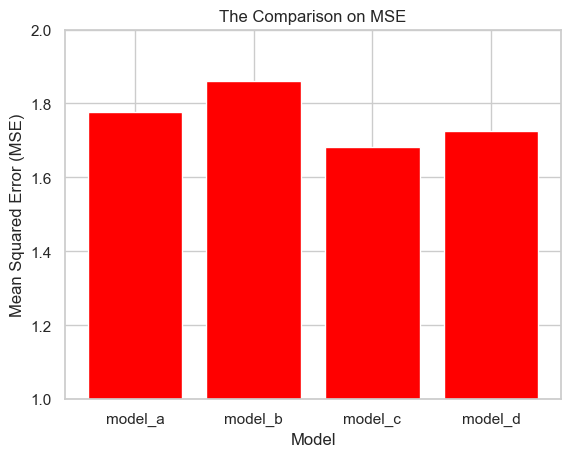

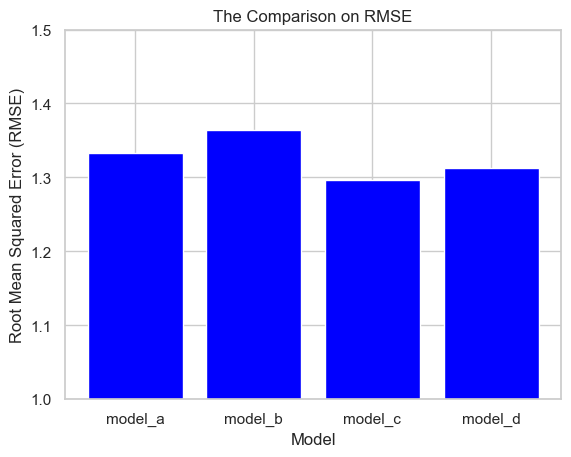

In [44]:
sns.set(style='whitegrid')
plt.ylim(1,2)
plt.bar(data=mse_data, height='mse', x=['model_a','model_b','model_c','model_d'], color='red')
plt.title("The Comparison on MSE")
plt.xlabel("Model")
plt.ylabel("Mean Squared Error (MSE)")
plt.show()

sns.set(style='whitegrid')
plt.ylim(1,1.5)
plt.bar(data=rmse_data, height='rmse', x=['model_a','model_b','model_c','model_d'], color='blue')
plt.title("The Comparison on RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.show()

__Analysis:__

1. __The more data, the less MSE and RMSE__

- Model C and Model D which are using case 2 data (training data containing 90% of the entire data) have obvouisly lower MSE (Mean Square Error) and RMSE (Root Mean Square Error) compared to Model A and Model B which are using case 1 data (training data containing 90% of the entire data)
    - it can be implied that the more trained data is used, the less error of data.
    
2. __The most correlated input features is always less error values than the least correlated input features.__

- Model A and Model C which are using the most correlated input features have less MSE and RMSE compared to Model B and MOdel D repectively, which are using the least correlated input features.
    - Correlation indicates MSE and RMSE values.

### Data Science Ethics
*Please read the following examples [Click here to read the example_1.](https://www.vox.com/covid-19-coronavirus-us-response-trump/2020/5/18/21262265/georgia-covid-19-cases-declining-reopening) [Click here to read the example_2.](https://viborc.com/ethics-and-ethical-data-visualization-a-complete-guide/)

*Then view the picture ![My Image](figure_portfolio2.png "This is my image")
Please compose an analysis of 100-200 words that evaluates potential ethical concerns associated with the infographic, detailing the reasons behind these issues.


__Potential Ethical Concerns__

The table infographic indicates the 2008 Olympic Medals by Country. There is comparison between 2 tables, table 1 is sorted by total medal, the USA is number 1. Table 2 is sorted by gold medal, China is number 1.

This infographic contains some problems on ethical principles, The first is the data accuracy. There is many incorrect data in both tables. For example, the USA got total 112 medals but infographic shows the USA got 110 medals. Plus, China got 48 gold medals but the infographic shows 51 gold medals. The accuracy of this data should be concerned, it can mislead or deceive the audience or lead to poor descison-making.

Second, Data source, the data do not have enough credibility and reliability of the source about who made the data, there are 2 references in diferrent year but do not know who made which one and where the data from. So, it can be considered potential biases or errors that the data present. 

Lastly, using "Britain" may be considered as a cultural sensitivities which is against inclusiveness ethical principle, the offical name in Olympics Games of The UK team should be "Great Britain (GBR)" which include the UK and overseas territories, not only countries from Britain island. 